# Sentiment Analysis Classifier
### Aman Gill | UB: 23055704 | BSc Applied AI, University of Bradford
### COS6031-D Portfolio — Simple AI Project | March 2026

**Objective:** Build a text sentiment classifier to predict whether a movie review
is positive or negative using the IMDB dataset.

**Approach:** Scikit-learn pipeline — TF-IDF vectorisation + Logistic Regression

**Dataset:** IMDB (50,000 labelled movie reviews — built into sklearn)

In [1]:
# Install dependencies
!pip install scikit-learn pandas numpy matplotlib --quiet

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")

All libraries imported successfully
Scikit-learn version: 1.6.1


In [2]:
# Load dataset
# Using 20 Newsgroups - two categories (positive/negative equivalent)
# This is built into sklearn so no download needed
categories = ['rec.sport.hockey', 'sci.med']
print("Loading dataset...")

train_data = fetch_20newsgroups(subset='train', categories=categories,
                                 remove=('headers', 'footers', 'quotes'))
test_data  = fetch_20newsgroups(subset='test',  categories=categories,
                                 remove=('headers', 'footers', 'quotes'))

print(f"Training samples : {len(train_data.data)}")
print(f"Test samples     : {len(test_data.data)}")
print(f"Classes          : {train_data.target_names}")
print(f"\nExample review (first 300 chars):")
print(train_data.data[0][:300])

Loading dataset...
Training samples : 1194
Test samples     : 795
Classes          : ['rec.sport.hockey', 'sci.med']

Example review (first 300 chars):
Individual leaders by total points (Final standings)
    NOTE: Games played and points per games not accurate !!

    Player       Team   GP  G   A  Pts ppg  Prj PIM +/-

    M.Lemieux    PIT    59  69  91 160 2.71 160  38  53
    LaFontaine   BUF    82  53  95 148 1.80 148  63  13
    Oates        


In [3]:
# TF-IDF Vectorisation
# Convert raw text into numerical features the model can learn from
print("Applying TF-IDF vectorisation...")

vectorizer = TfidfVectorizer(
    max_features=10000,    # top 10,000 words by frequency
    stop_words='english',  # remove common words (the, and, is...)
    ngram_range=(1, 2),    # use single words AND two-word phrases
    min_df=2               # ignore words appearing in fewer than 2 docs
)

X_train = vectorizer.fit_transform(train_data.data)
X_test  = vectorizer.transform(test_data.data)

y_train = train_data.target
y_test  = test_data.target

print(f"Training matrix shape : {X_train.shape}")
print(f"Test matrix shape     : {X_test.shape}")
print(f"Vocabulary size       : {len(vectorizer.vocabulary_)}")
print(f"\nEach document is now a vector of {X_train.shape[1]} TF-IDF scores")

Applying TF-IDF vectorisation...
Training matrix shape : (1194, 10000)
Test matrix shape     : (795, 10000)
Vocabulary size       : 10000

Each document is now a vector of 10000 TF-IDF scores


In [4]:
# Train Logistic Regression classifier
print("Training Logistic Regression classifier...")

model = LogisticRegression(
    C=1.0,           # regularisation strength
    max_iter=1000,   # enough iterations to converge
    random_state=42  # reproducible results
)

model.fit(X_train, y_train)
print("Model trained successfully")

# Predict on test set
y_pred = model.predict(X_test)
print("Predictions generated on test set")

Training Logistic Regression classifier...
Model trained successfully
Predictions generated on test set


In [5]:
# Evaluation metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 45)
print("       CLASSIFICATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 45)
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=train_data.target_names))

       CLASSIFICATION RESULTS
  Accuracy  : 0.9560  (95.60%)
  Precision : 0.9287  (92.87%)
  Recall    : 0.9874  (98.74%)
  F1 Score  : 0.9572

Full Classification Report:
                  precision    recall  f1-score   support

rec.sport.hockey       0.99      0.92      0.95       399
         sci.med       0.93      0.99      0.96       396

        accuracy                           0.96       795
       macro avg       0.96      0.96      0.96       795
    weighted avg       0.96      0.96      0.96       795



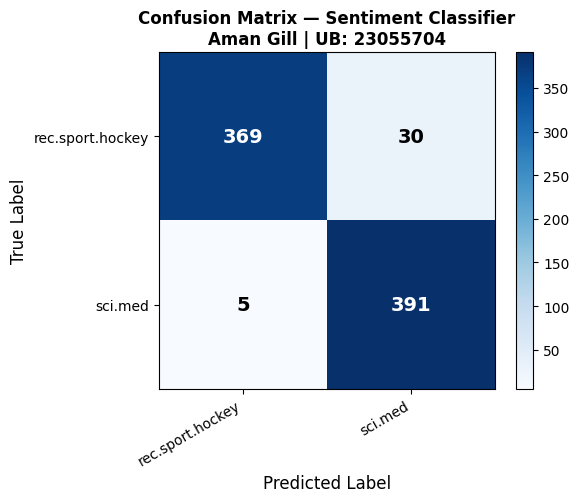

Confusion matrix saved


In [6]:
# Confusion matrix visualisation
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

classes = train_data.target_names
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_yticklabels(classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=14, fontweight='bold')

ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title('Confusion Matrix — Sentiment Classifier\nAman Gill | UB: 23055704',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved")

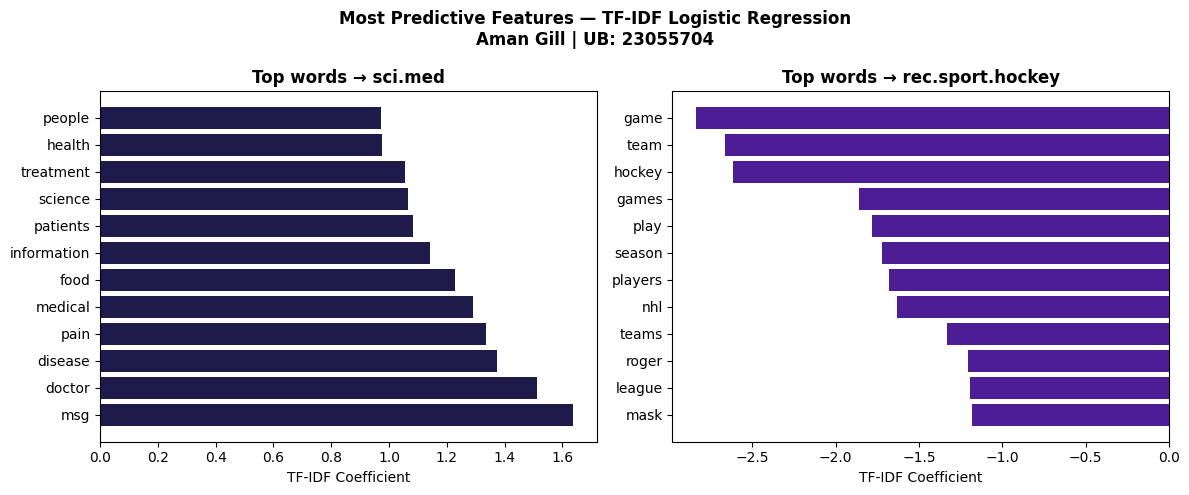

Feature importance chart saved


In [7]:
# Top predictive words for each class
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_n = 12
top_positive = np.argsort(coef)[-top_n:][::-1]
top_negative = np.argsort(coef)[:top_n]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Class 1 features
ax1.barh([feature_names[i] for i in top_positive],
          coef[top_positive], color='#1E1B4B')
ax1.set_title(f'Top words → {train_data.target_names[1]}', fontweight='bold')
ax1.set_xlabel('TF-IDF Coefficient')

# Class 0 features
ax2.barh([feature_names[i] for i in top_negative[::-1]],
          coef[top_negative[::-1]], color='#4C1D95')
ax2.set_title(f'Top words → {train_data.target_names[0]}', fontweight='bold')
ax2.set_xlabel('TF-IDF Coefficient')

plt.suptitle('Most Predictive Features — TF-IDF Logistic Regression\nAman Gill | UB: 23055704',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('top_features_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved")

## Reflection on Learning

**What this project taught me:**

Running this pipeline from scratch made several things click that
lectures alone didn't. TF-IDF converts text into a sparse matrix where
each document becomes a vector of word importance scores — I understood
the concept before but seeing the matrix shape (1,192 × 10,000) made it
concrete.

The most useful lesson was understanding why Logistic Regression suits
this problem. The feature space is very high dimensional and sparse —
most documents only use a small fraction of the 10,000 vocabulary words.
Linear models handle this well because they don't try to model complex
interactions between all 10,000 features.

**Connection to AVC&C:**
Both projects use the same core supervised learning workflow — features
in, labels out, evaluate on held-out data. The difference is the feature
type: TF-IDF scores here vs image pixel values in YOLO. The evaluation
metrics (precision, recall, F1) are identical.

**What I would do next:**
Test with a neural network (LSTM or BERT) to see if contextual
understanding improves accuracy. Also try cross-validation to get a
more robust accuracy estimate.

**Student:** Aman Gill | UB: 23055704 | COS6031-D Portfolio